# HOuse Model

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.linear_model import LinearRegression 
import warnings
warnings.filterwarnings('ignore')

# DATA LOAD -  DATA CLean

In [2]:
df = pd.read_csv('../data/kc_house_data.csv')

In [3]:
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


# EDA

In [4]:
col =['price', 'bedrooms' , 'bathrooms' , 'sqft_living' , 'sqft_lot' ,'floors']

In [5]:
df_clean =df[col]

In [6]:
df_clean.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors
0,221900.0,3,1.00,1180,5650,1.0
1,538000.0,3,2.25,2570,7242,2.0
2,180000.0,2,1.00,770,10000,1.0
3,604000.0,4,3.00,1960,5000,1.0
4,510000.0,3,2.00,1680,8080,1.0


In [7]:
df_clean.isna().sum()

price          0
bedrooms       0
bathrooms      0
sqft_living    0
sqft_lot       0
floors         0
dtype: int64

price , bedrooms , bathrooms , sqft_living , sqft_lot , floors , 

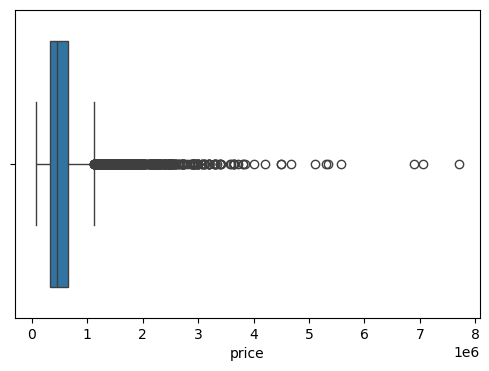

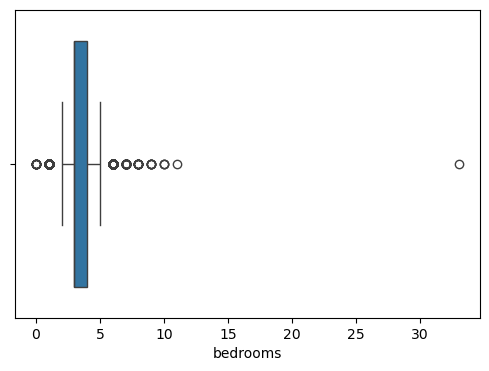

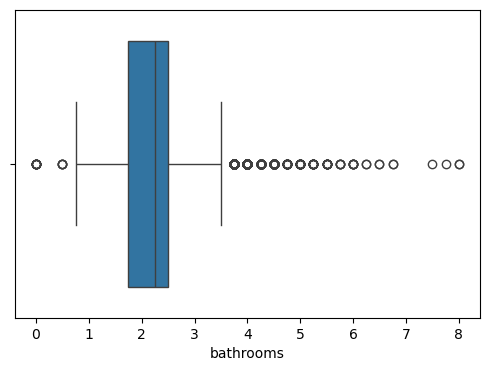

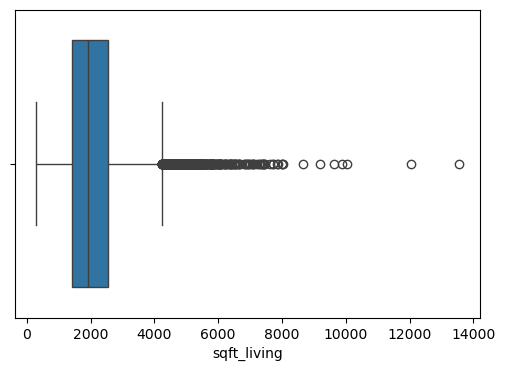

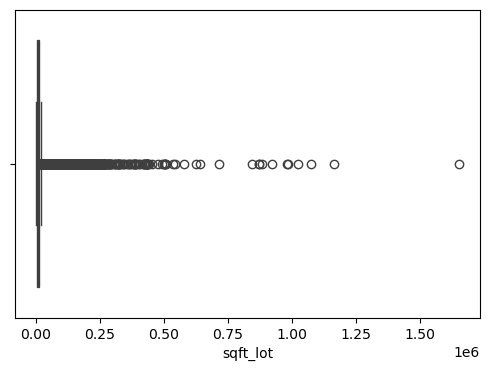

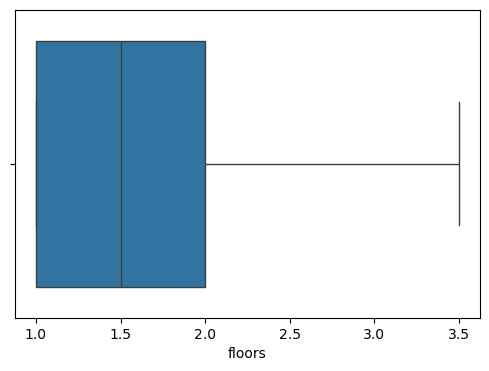

In [8]:
col =['price', 'bedrooms' , 'bathrooms' , 'sqft_living' , 'sqft_lot' ,'floors']
for i in col:
    print(i , end = " , ")
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df_clean[i])

In [9]:
df_clean.duplicated().sum()

np.int64(10)

In [10]:
df_clean.drop_duplicates(inplace=True)
df_clean.duplicated().sum()

np.int64(0)

# Remove Outliers

In [11]:
col =['bedrooms' , 'bathrooms' , 'sqft_living' , 'sqft_lot' ,'floors']

for col in col:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    # print("value :",df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)])
    df_clean = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]


price , bedrooms , bathrooms , sqft_living , sqft_lot , floors , 

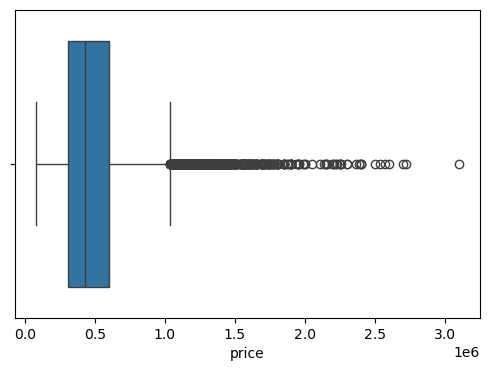

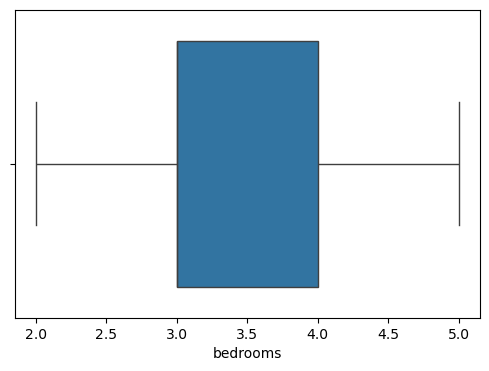

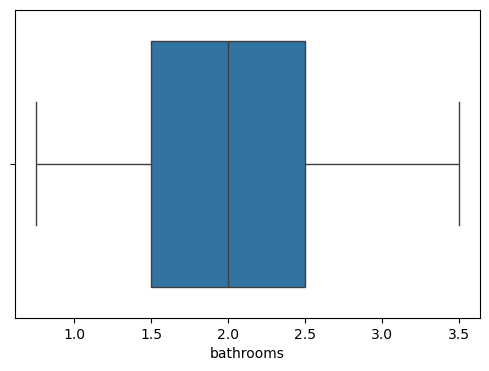

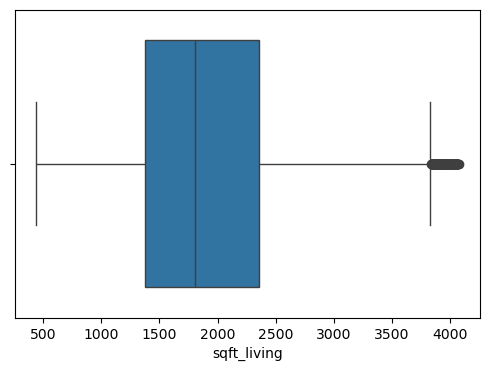

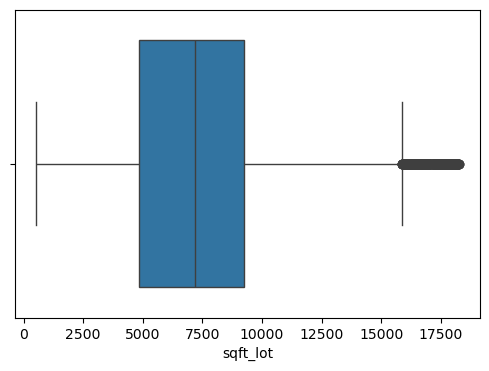

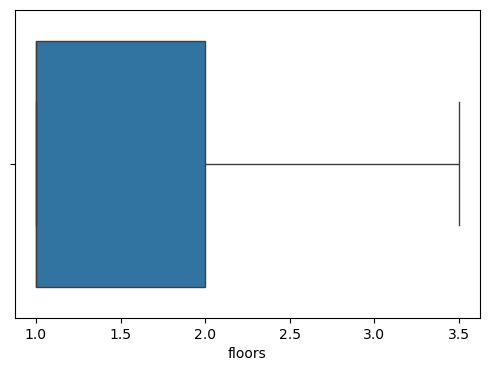

In [12]:
col =['price','bedrooms' , 'bathrooms' , 'sqft_living' , 'sqft_lot' ,'floors']
for i in col:
    print(i , end = " , ")
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df_clean[i])

In [13]:
df_clean.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors
0,221900.0,3,1.00,1180,5650,1.0
1,538000.0,3,2.25,2570,7242,2.0
2,180000.0,2,1.00,770,10000,1.0
3,604000.0,4,3.00,1960,5000,1.0
4,510000.0,3,2.00,1680,8080,1.0


<Axes: >

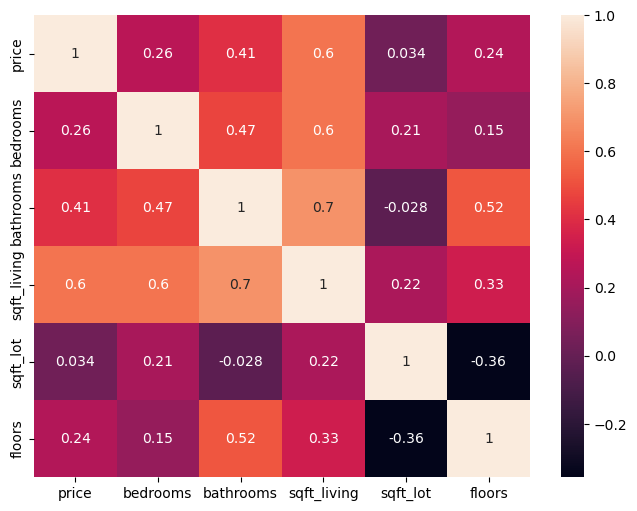

In [14]:
plt.figure(figsize=(8,6))
sns.heatmap(df_clean.corr(numeric_only=True),annot=True)

# Regression Model

Slop  : -47004
Inercept   : 209254


Enter number of bedrooms:  4
Enter number of bathrooms:  12
Enter living area (sqft):  45
Enter lot area (sqft):  1200
Enter number of floors:  88


predicted price :  ₹-166549.16


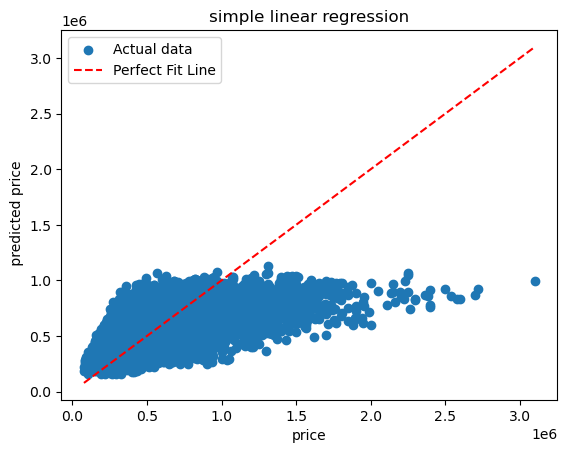

In [16]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.linear_model import LinearRegression 
import warnings
warnings.filterwarnings('ignore')
X=df_clean[["bedrooms" ,"bathrooms" , "sqft_living" , "sqft_lot" , "floors"]]
y=df_clean["price"]

model=LinearRegression()
model.fit(X,y)

print("Slop  :" ,round(model.coef_[0]))
print("Inercept   :" , round(model.intercept_))

bedrooms = int(input("Enter number of bedrooms: "))
bathrooms = float(input("Enter number of bathrooms: "))
sqft_living = int(input("Enter living area (sqft): "))
sqft_lot = int(input("Enter lot area (sqft): "))
floors = float(input("Enter number of floors: "))
price=model.predict([[bedrooms , bathrooms , sqft_living , sqft_lot , floors]])

print(f"predicted price :  ₹{price[0]:.2f}")

plt.scatter(y, model.predict(X),label="Actual data")
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', linestyle='--', label='Perfect Fit Line')
plt.xlabel("price")
plt.ylabel(" predicted price")
plt.title("simple linear regression")
plt.legend()
plt.show()

In [15]:
df_clean.to_csv("kc_house_clean_data.csv", index=False)

In [16]:
df_clean.columns

Index(['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors'], dtype='object')